In [50]:
from unittest.mock import inplace

import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt


In [51]:
df=pd.read_csv("weatherAUS.csv",na_values=['',' ','/','-','NA'])

In [52]:
df=df.sample(10000,random_state=42)

In [53]:
df.isna().sum()

Date                0
Location            0
MinTemp           103
MaxTemp            87
Rainfall          216
Evaporation      4244
Sunshine         4766
WindGustDir       719
WindGustSpeed     717
WindDir9am        737
WindDir3pm        286
WindSpeed9am      124
WindSpeed3pm      201
Humidity9am       188
Humidity3pm       301
Pressure9am      1030
Pressure3pm      1018
Cloud9am         3779
Cloud3pm         3996
Temp9am           130
Temp3pm           240
RainToday         216
RainTomorrow      219
dtype: int64

In [54]:
df['WillRain']=df['RainTomorrow'].map({'Yes':1,'No':0})

In [55]:
df.isna().sum()

Date                0
Location            0
MinTemp           103
MaxTemp            87
Rainfall          216
Evaporation      4244
Sunshine         4766
WindGustDir       719
WindGustSpeed     717
WindDir9am        737
WindDir3pm        286
WindSpeed9am      124
WindSpeed3pm      201
Humidity9am       188
Humidity3pm       301
Pressure9am      1030
Pressure3pm      1018
Cloud9am         3779
Cloud3pm         3996
Temp9am           130
Temp3pm           240
RainToday         216
RainTomorrow      219
WillRain          219
dtype: int64

In [56]:
df.drop(columns='Evaporation',inplace=True)
df.drop(columns='Sunshine',inplace=True)
df.drop(columns='Cloud9am',inplace=True)
df.drop(columns='Cloud3pm',inplace=True)


In [57]:

df.drop(columns='Date',inplace=True)
df.drop(columns='Location',inplace=True)
df.drop(columns='WindGustDir',inplace=True)
df.drop(columns='WindDir9am',inplace=True)
df.drop(columns='WindDir3pm',inplace=True)
df.drop(columns='RainTomorrow',inplace=True)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 100721 to 68844
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MinTemp        9897 non-null   float64
 1   MaxTemp        9913 non-null   float64
 2   Rainfall       9784 non-null   float64
 3   WindGustSpeed  9283 non-null   float64
 4   WindSpeed9am   9876 non-null   float64
 5   WindSpeed3pm   9799 non-null   float64
 6   Humidity9am    9812 non-null   float64
 7   Humidity3pm    9699 non-null   float64
 8   Pressure9am    8970 non-null   float64
 9   Pressure3pm    8982 non-null   float64
 10  Temp9am        9870 non-null   float64
 11  Temp3pm        9760 non-null   float64
 12  RainToday      9784 non-null   object 
 13  WillRain       9781 non-null   float64
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [59]:
df['RainToday'].value_counts()

RainToday
No     7623
Yes    2161
Name: count, dtype: int64

In [60]:
df['RainToday']=df['RainToday'].map({'Yes':1,'No':0})

In [61]:
df['RainToday'].value_counts()

RainToday
0.0    7623
1.0    2161
Name: count, dtype: int64

In [62]:
df.isna().sum()

MinTemp           103
MaxTemp            87
Rainfall          216
WindGustSpeed     717
WindSpeed9am      124
WindSpeed3pm      201
Humidity9am       188
Humidity3pm       301
Pressure9am      1030
Pressure3pm      1018
Temp9am           130
Temp3pm           240
RainToday         216
WillRain          219
dtype: int64

In [64]:
from scipy.stats import shapiro

for col in df.columns:
    stats,p=shapiro(df[col].dropna())
    if p<0.05:
        print(col," Nema Normalnu")
    else:
        print(col," Ima Normalnu")

MinTemp  Nema Normalnu
MaxTemp  Nema Normalnu
Rainfall  Nema Normalnu
WindGustSpeed  Nema Normalnu
WindSpeed9am  Nema Normalnu
WindSpeed3pm  Nema Normalnu
Humidity9am  Nema Normalnu
Humidity3pm  Nema Normalnu
Pressure9am  Nema Normalnu
Pressure3pm  Nema Normalnu
Temp9am  Nema Normalnu
Temp3pm  Nema Normalnu
RainToday  Nema Normalnu
WillRain  Nema Normalnu


C:\Users\INSOMNIA\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9897.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\INSOMNIA\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9913.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\INSOMNIA\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9784.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\INSOMNIA\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9283.

In [ ]:
# kako je pvrednost manja od praga <0.05 onda nemaju Normlanu Raspodelu , menjamo Na vrednosti sa Medianom .

In [65]:
for col in df.columns:
    df[col]=df[col].fillna(df[col].median())


In [66]:
df.isna().sum()

MinTemp          0
MaxTemp          0
Rainfall         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
WillRain         0
dtype: int64

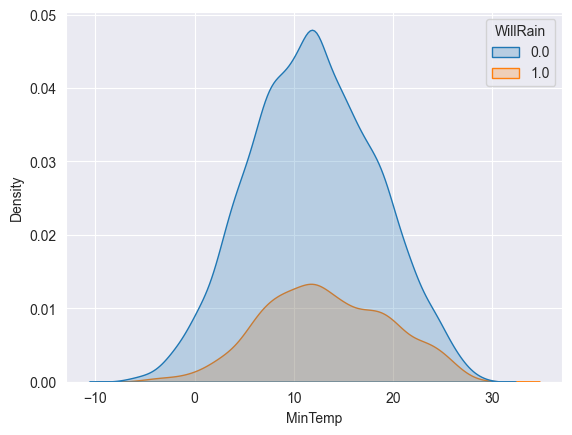

In [67]:
plt.figure()
sb.kdeplot(x=df['MinTemp'],hue=df['WillRain'],fill=True)
plt.show()

In [69]:
df.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'WillRain'],
      dtype='object')

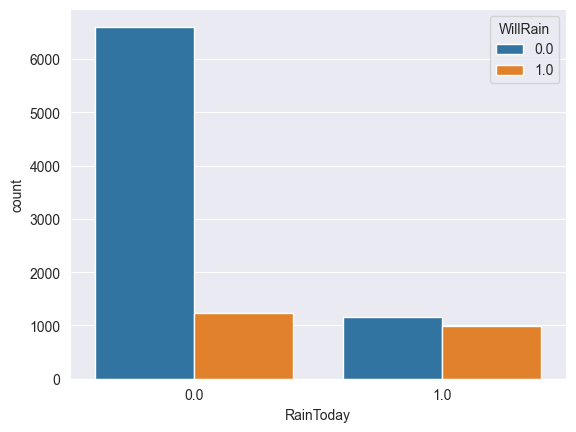

In [97]:
plt.figure()
sb.countplot(x=df['RainToday'],hue=df['WillRain'],fill=True)
plt.show()

In [75]:
df['Rainfall'].describe()
#

count    10000.000000
mean         2.278840
std          9.287117
min          0.000000
25%          0.000000
50%          0.000000
75%          0.600000
max        367.600000
Name: Rainfall, dtype: float64

In [92]:
df.drop(columns='Temp9am',inplace=True)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 100721 to 68844
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MinTemp        10000 non-null  float64
 1   MaxTemp        10000 non-null  float64
 2   WindGustSpeed  10000 non-null  float64
 3   WindSpeed9am   10000 non-null  float64
 4   Humidity3pm    10000 non-null  float64
 5   Pressure9am    10000 non-null  float64
 6   Pressure3pm    10000 non-null  float64
 7   Temp3pm        10000 non-null  float64
 8   RainToday      10000 non-null  float64
 9   WillRain       10000 non-null  float64
dtypes: float64(10)
memory usage: 859.4 KB


In [99]:
df.describe()

,MinTemp,MaxTemp,WindGustSpeed,WindSpeed9am,Humidity3pm,Pressure9am,Pressure3pm,Temp3pm,RainToday,WillRain
count,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,12.188540,23.223820,39.99070,14.03470,51.537900,1017.598960,1015.208450,21.662990,0.216100,0.222800
std,6.344544,7.097512,12.93086,8.85574,20.697169,6.633993,6.551022,6.866089,0.411604,0.416146
min,-7.500000,-3.700000,7.00000,0.00000,1.000000,982.300000,984.200000,-4.100000,0.000000,0.000000
25%,7.600000,18.000000,31.00000,7.00000,37.000000,1013.600000,1010.900000,16.800000,0.000000,0.000000
50%,12.000000,22.600000,39.00000,13.00000,52.000000,1017.500000,1015.100000,21.200000,0.000000,0.000000
75%,16.800000,28.300000,46.00000,19.00000,65.000000,1021.500000,1019.300000,26.300000,0.000000,0.000000
max,30.700000,48.100000,135.00000,67.00000,100.000000,1040.400000,1037.700000,46.100000,1.000000,1.000000


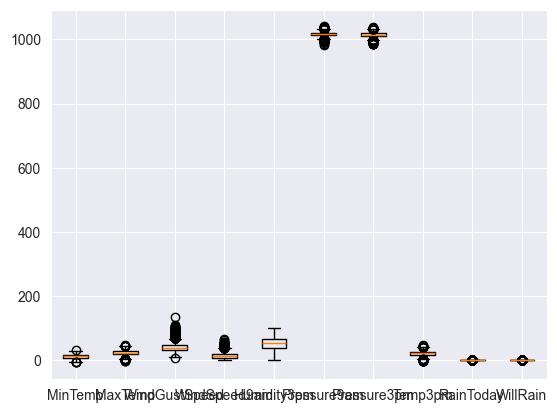

In [101]:
plt.boxplot(df,tick_labels=df.columns)
plt.tight_layout
plt.show()

In [103]:
#posto imaju outliere ne koristimo MinMax scaler koji zahteva nepostojanje istih
# proverili smo gore raspodele i videl ida nemaju normalnu tako da cemo da radibmo robust scaler.

In [109]:
df['WillRain']

100721    1.0
30234     0.0
68427     0.0
28624     0.0
31173     0.0
         ... 
60036     0.0
45194     0.0
121445    0.0
30967     0.0
68844     1.0
Name: WillRain, Length: 10000, dtype: float64

In [104]:
from sklearn.preprocessing import RobustScaler

scaler=RobustScaler()
df_scaled=pd.DataFrame(data=scaler.fit_transform(df),columns=df.columns)

In [110]:
from sklearn.model_selection import train_test_split
X=df_scaled.drop(columns='WillRain')
y=df_scaled['WillRain']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y)

In [113]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV


paramgrid={'n_neighbors':np.arange(3,26,2)}
clf = GridSearchCV(KNeighborsClassifier(),param_grid=paramgrid,n_jobs=-1,cv=10,verbose=1)
clf.fit(X_train,y_train)
#optimalno n_neighbors

Fitting 10 folds for each of 12 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': array([ 3, 5..., 21, 23, 25])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [116]:
clf.get_params()

{'cv': 10,
 'error_score': nan,
 'estimator__algorithm': 'auto',
 'estimator__leaf_size': 30,
 'estimator__metric': 'minkowski',
 'estimator__metric_params': None,
 'estimator__n_jobs': None,
 'estimator__n_neighbors': 5,
 'estimator__p': 2,
 'estimator__weights': 'uniform',
 'estimator': KNeighborsClassifier(),
 'n_jobs': -1,
 'param_grid': {'n_neighbors': array([ 3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25])},
 'pre_dispatch': '2*n_jobs',
 'refit': True,
 'return_train_score': False,
 'scoring': None,
 'verbose': 1}

In [117]:
neigh = KNeighborsClassifier(n_neighbors=19)
neigh.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",19
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [119]:
y_pred=neigh.predict(X_test)

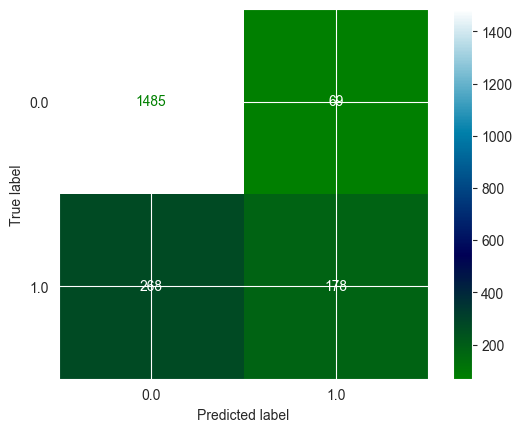

In [121]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,precision_recall_fscore_support
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred),
                         display_labels=clf.classes_)
disp.plot(cmap="ocean")